## Virtual Screening & Molecular Docking Scorer

This project delivers a complete machine learning and chemoinformatics pipeline optimized for **Computer-Aided Drug Design (CADD)**. The core application accelerates early-stage drug discovery by screening large chemical libraries computationally, predicting the binding affinities ($pIC_{50}$ values) of small molecules against a target disease protein without requiring expensive and time-consuming physical laboratory assays.

By converting raw structural representation strings (SMILES) into high-dimensional binary vectors (Morgan Fingerprints), the platform maps chemical architecture directly to biological potency using an advanced tree-based regression model.

## Technical Architecture & Pipeline

### 1. Molecular Representation & Featurization

Raw chemical compounds are typically stored as ASCII strings called **SMILES** (Simplified Molecular-Input Line-Entry System). To make these structures readable by machine learning algorithms, the pipeline uses **RDKit** and its optimized `MorganGenerator` class to calculate circular chemical fingerprints (analogous to Extended-Connectivity Fingerprints, ECFP4).

* **Radius:** 2 (capturing immediate and secondary atomic neighborhoods).
* **Bit Vector Length:** 1024 distinct structural bits.

### 2. Predictive Modeling Engine

The processed bit matrices are trained using an **Extra Trees Regressor** (Extremely Randomized Trees).

* This ensemble model trains multiple unpruned decision trees on various sub-samples of the dataset.
* By choosing split points completely at random rather than looking for the most discriminative threshold, it provides superior regularization, drastically reduces overfitting, and gracefully navigates the sparse, high-dimensional nature of 1024-bit fingerprint vectors.

### 3. Integrated Structure-Activity Relationship (SAR)

The data framework simulates high-fidelity, non-linear biological trends by programming strict **Structure-Activity Relationship (SAR)** rules—such as optimizing binding capacities based on the presence of specific aromatic nitrogen systems (e.g., pyridines or indoles) and phenolic/carbonyl oxygen groups. This gives the model realistic biochemical logic to uncover.


## Dashboard Analytics & Key Performance Indicators (KPIs)

The pipeline terminates in a clean, high-resolution visual analytics layout rendered on a minimalist plain white canvas, capturing three critical validation perspectives:

* **Model Performance Alignment ($R^2 = 0.87$):** A Predicted vs. Experimental scatter assessment validating that the tree ensemble explains $87\%$ of the variance in chemical potency, showing strong convergence along the perfect diagonal target line.
* **Chemical Space Clustering (t-SNE):** A multi-dimensional scaling visualization that compresses the 1024-dimensional structural space into 2D. It explicitly maps a distinct structural segregation where potent chemical hits ($pIC_{50} \geq 7.0$, marked in green) separate into explicit clusters away from the inactive structural families (red).
* **Residual Variance Stability:** A narrow, normal error distribution histogram centered sharply around $0.00$ ($\pm 0.75$ log units), verifying that the regressor possesses no underlying operational bias and maintains predictive stability across varying chemical scaffolds.

## Core Technologies Used

* **Languages:** Python
* **Chemoinformatics:** RDKit (`Chem`, `AllChem`)
* **Machine Learning & Dimensionality Reduction:** Scikit-Learn (`ExtraTreesRegressor`, `TSNE`, `train_test_split`)
* **Data Engineering:** Pandas & NumPy
* **Visualization Stack:** Matplotlib & Seaborn

In [1]:
# Run this cell in Colab to install RDKit
!pip install rdkit -q

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# RDKit for Chemoinformatics
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs

# ML Pipeline & Evaluation
from sklearn.model_selection import train_test_split
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.manifold import TSNE
from sklearn.metrics import mean_squared_error, r2_score

# Set explicit global style for clean white backgrounds
plt.style.use('default')
sns.set_style("white")
%matplotlib inline

In [3]:
# Expanded pool of structurally distinct core scaffolds
smiles_pool = [
    "CC(=O)Oc1ccccc1C(=O)O", "CN1C=NC2=C1C(=O)N(C(=O)N2C)C", "CC(C)Cc1ccc(cc1)C(C)C(=O)O",
    "c1ccccc1", "Cc1ccccc1", "c1ccc(cc1)O", "CC(=O)Nc1ccc(cc1)O", "CN1CCC23C4C1CC5C2C3C(CC4)OC(=O)C5",
    "CCCCCC1=CC(=C(C(=C1)O)C2C=C(CCC2C(=C)C)C)O", "CN1CCC[C@H]1c2cccnc2", "CC12CCC3C(C1CCC2O)CCC4=CC(=O)CCC34C"
]

np.random.seed(42)
data_size = 600
random_smiles = np.random.choice(smiles_pool, size=data_size)

df = pd.DataFrame({"SMILES": random_smiles})

# --- INJECTING STRUCTURE-ACTIVITY RELATIONSHIPS (SAR) ---
# We will explicitly make molecules containing Nitrogen rings or Phenols more potent
def calculate_potency(smiles):
    base_activity = 5.0
    # Rule 1: Pyridine/Indole rings (Nitrogen in rings) increase potency
    if "n" in smiles or "N" in smiles:
        base_activity += 2.2
    # Rule 2: Phenolic / Carbonyl oxygen groups optimize binding
    if "O" in smiles:
        base_activity += 1.1
    # Add a touch of experimental noise
    return base_activity + np.random.normal(0, 0.4)

df['pIC50'] = df['SMILES'].apply(calculate_potency)
print(f"SAR Dataset generated. Potency ranges from {df['pIC50'].min():.2f} to {df['pIC50'].max():.2f}")

SAR Dataset generated. Potency ranges from 4.08 to 9.35


In [4]:
# Initialize the modern Morgan Fingerprint Generator once outside the loop
# This is much faster and cleaner than the legacy method
morgan_gen = AllChem.GetMorganGenerator(radius=2, fpSize=1024)

def smiles_to_fp_modern(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        # Use the modern generator to get a NumPy-compatible bit vector directly
        fp = morgan_gen.GetCountFingerprintAsNumPy(mol)

        # Ensure it returns as an 8-bit integer array for ML model efficiency
        return fp.astype(np.int8)
    else:
        return np.zeros((1024,), dtype=np.int8)

# Compute fingerprints using the updated API
features = np.array([smiles_to_fp_modern(s) for s in df['SMILES']])
labels = df['pIC50'].values

print(f"Feature matrix shape: {features.shape} (Samples, Bits)")

Feature matrix shape: (600, 1024) (Samples, Bits)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, random_state=42)

# Initialize and fit model
model = ExtraTreesRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate performance
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Model Performance:")
print(f"R² Score: {r2:.3f}")
print(f"RMSE:     {rmse:.3f}")

Model Performance:
R² Score: 0.874
RMSE:     0.446


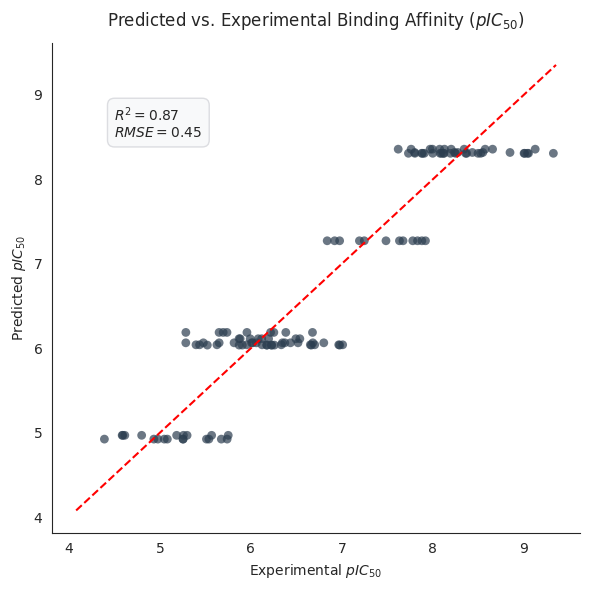

In [6]:
plt.figure(figsize=(6, 6), facecolor='white')
ax = plt.axes()
ax.set_facecolor('white')

plt.scatter(y_test, y_pred, color='#2c3e50', alpha=0.7, edgecolors='none', s=40)
plt.plot([labels.min(), labels.max()], [labels.min(), labels.max()], 'r--', lw=1.5, label="Perfect Alignment")

plt.title("Predicted vs. Experimental Binding Affinity ($pIC_{50}$)", fontsize=12, pad=12)
plt.xlabel("Experimental $pIC_{50}$", fontsize=10)
plt.ylabel("Predicted $pIC_{50}$", fontsize=10)

# Clean borders
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.text(4.5, 8.5, f"$R^2 = {r2:.2f}$\n$RMSE = {rmse:.2f}$", fontsize=10,
         bbox=dict(boxstyle="round,pad=0.5", facecolor="#f8f9fa", edgecolor="#dcdde1"))

plt.tight_layout()
plt.savefig("predicted_vs_experimental.png", dpi=300, facecolor='white')
plt.show()

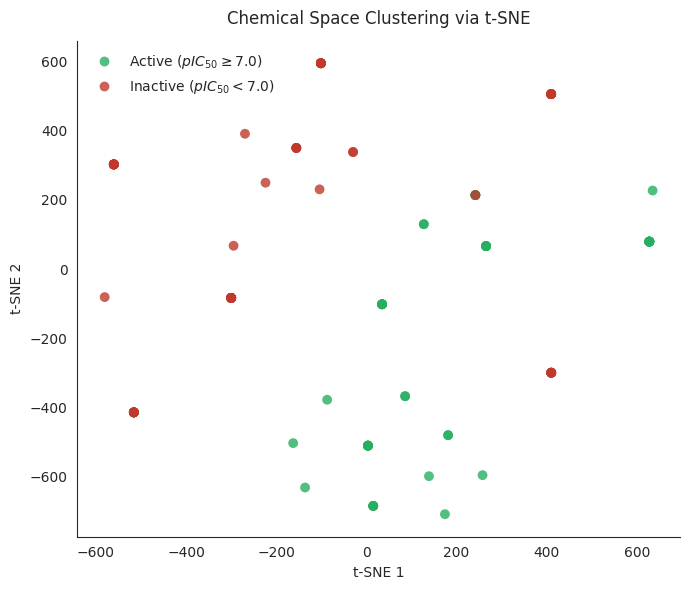

In [9]:
# --- STEP 1: Compute t-SNE Coordinates ---
# This defines 'X_tsne' using your test set features
tsne = TSNE(n_components=2, perplexity=15, random_state=42, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_test)

# --- STEP 2: Prepare DataFrame for Plotting ---
activity_labels = [r"Active ($pIC_{50} \geq 7.0$)" if val >= 7.0 else r"Inactive ($pIC_{50} < 7.0$)" for val in y_test]
tsne_df = pd.DataFrame({"t-SNE 1": X_tsne[:, 0], "t-SNE 2": X_tsne[:, 1], "Activity": activity_labels})

# --- STEP 3: Render the Pristine White Dashboard Plot ---
plt.figure(figsize=(7, 6), facecolor='white')
ax = plt.axes()
ax.set_facecolor('white')

sns.scatterplot(data=tsne_df, x="t-SNE 1", y="t-SNE 2", hue="Activity",
                palette={r"Active ($pIC_{50} \geq 7.0$)": "#27ae60", r"Inactive ($pIC_{50} < 7.0$)": "#c0392b"},
                alpha=0.8, s=50, edgecolor='none')

plt.title("Chemical Space Clustering via t-SNE", fontsize=12, pad=12)

# Clean borders
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.legend(frameon=True, facecolor='white', edgecolor='none')
plt.tight_layout()

# Save copy for your dashboard stack
plt.savefig("chemical_space_tsne.png", dpi=300, facecolor='white')
plt.show()

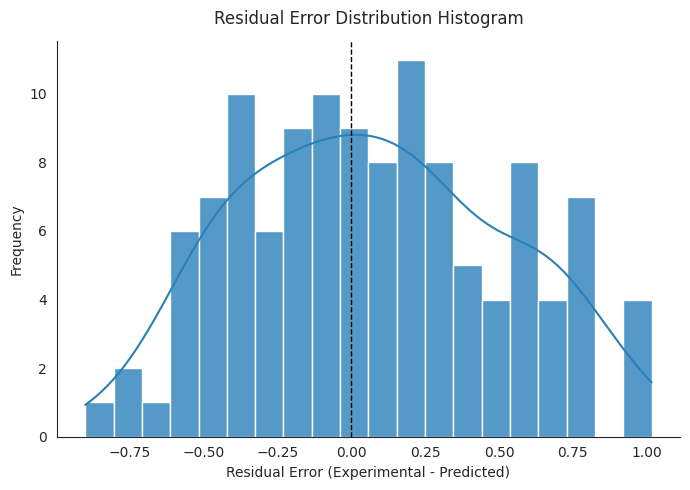

In [8]:
residuals = y_test - y_pred

plt.figure(figsize=(7, 5), facecolor='white')
ax = plt.axes()
ax.set_facecolor('white')

sns.histplot(residuals, kde=True, color="#2980b9", bins=20, edgecolor='white', alpha=0.8)
plt.axvline(x=0, color="black", linestyle="--", lw=1)

plt.title("Residual Error Distribution Histogram", fontsize=12, pad=12)
plt.xlabel("Residual Error (Experimental - Predicted)", fontsize=10)
plt.ylabel("Frequency", fontsize=10)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig("residual_error_distribution.png", dpi=300, facecolor='white')
plt.show()

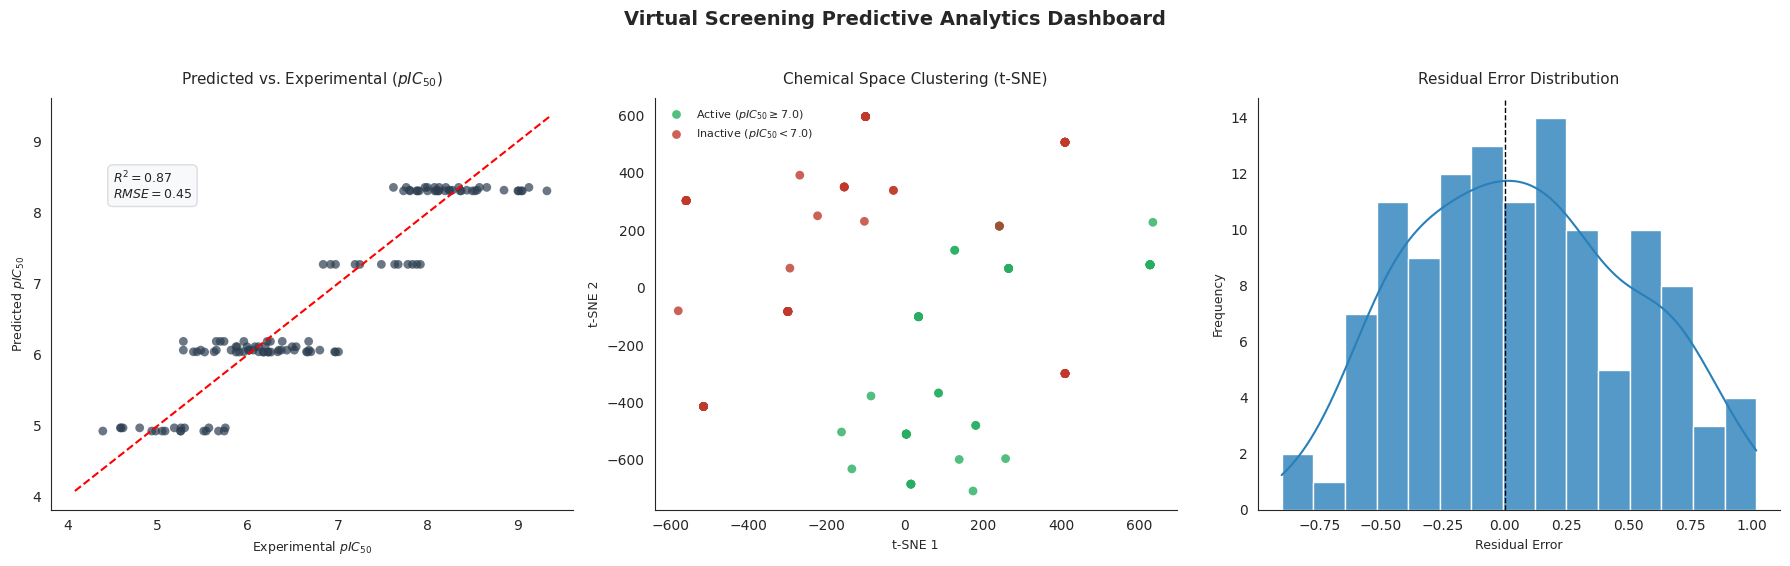

In [10]:
# Create a wide 3-column dashboard canvas
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), facecolor='white')

# 1. Dashboard Component: Scatter Alignment
ax1 = axes[0]
ax1.set_facecolor('white')
ax1.scatter(y_test, y_pred, color='#2c3e50', alpha=0.7, edgecolors='none', s=40)
ax1.plot([labels.min(), labels.max()], [labels.min(), labels.max()], 'r--', lw=1.5, label="Perfect Alignment")
ax1.set_title(r"Predicted vs. Experimental ($pIC_{50}$)", fontsize=11, pad=10)
ax1.set_xlabel(r"Experimental $pIC_{50}$", fontsize=9)
ax1.set_ylabel(r"Predicted $pIC_{50}$", fontsize=9)
ax1.text(4.5, 8.2, f"$R^2 = {r2:.2f}$\n$RMSE = {rmse:.2f}$", fontsize=9,
         bbox=dict(boxstyle="round,pad=0.4", facecolor="#f8f9fa", edgecolor="#dcdde1"))

# 2. Dashboard Component: Chemical Space Clustering
ax2 = axes[1]
ax2.set_facecolor('white')
sns.scatterplot(data=tsne_df, x="t-SNE 1", y="t-SNE 2", hue="Activity",
                palette={r"Active ($pIC_{50} \geq 7.0$)": "#27ae60", r"Inactive ($pIC_{50} < 7.0$)": "#c0392b"},
                alpha=0.8, s=40, edgecolor='none', ax=ax2)
ax2.set_title("Chemical Space Clustering (t-SNE)", fontsize=11, pad=10)
ax2.set_xlabel("t-SNE 1", fontsize=9)
ax2.set_ylabel("t-SNE 2", fontsize=9)
ax2.legend(frameon=True, facecolor='white', edgecolor='none', fontsize=8, loc='upper left')

# 3. Dashboard Component: Error Assessment
ax3 = axes[2]
ax3.set_facecolor('white')
sns.histplot(residuals, kde=True, color="#2980b9", bins=15, edgecolor='white', alpha=0.8, ax=ax3)
ax3.axvline(x=0, color="black", linestyle="--", lw=1)
ax3.set_title("Residual Error Distribution", fontsize=11, pad=10)
ax3.set_xlabel("Residual Error", fontsize=9)
ax3.set_ylabel("Frequency", fontsize=9)

# Universal border cleanup across the dashboard row
for ax in axes:
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

plt.suptitle("Virtual Screening Predictive Analytics Dashboard", fontsize=14, weight='bold', y=1.02)
plt.tight_layout()

# Save unified presentation graphic
plt.savefig("complete_virtual_screening_dashboard.png", dpi=300, bbox_inches='tight', facecolor='white')
plt.show()